# Бинарный классификатор на целевой признак IC50 > median(IC50)

In [14]:
import pandas as pd
import numpy as np

## Настройка

In [15]:
from pathlib import Path


RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5

ALL_TARGET_COLS = [
    "pIC50",
    "pCC50",
    "log1p_SI",
    "IC50, mM", 
    "CC50, mM", 
    "SI"
]

DATA_FOR_MODEL_PATH = Path('./output/indata_processed.csv')

## Загрузка данных

In [16]:
from dataclasses import dataclass, field
from sklearn.model_selection import train_test_split


@dataclass
class Dataset:
    X_train: pd.DataFrame
    X_test: pd.DataFrame
    y_train: pd.Series
    y_test: pd.Series
    feature_names: list[str]
    y_column: str


# загрузка датасета
def load_data():
    if not DATA_FOR_MODEL_PATH.exists():
        raise FileNotFoundError("Не найден файл подготовленных данных")
    return pd.read_csv(DATA_FOR_MODEL_PATH)


# проврека целевая или нет
def is_target_col(name: str):
    if name in ALL_TARGET_COLS:
        return True
    else:
        return False
    

# список признаков
def get_feature_cols(df: pd.DataFrame):
    return [c for c in df.columns if not is_target_col(c)]


# подготовка данных для обучения
def prepare_dataset(df: pd.DataFrame, y_col: str):
    if y_col not in df.columns:
        raise ValueError(f"Столбец {y_col} отсутствует в данных")
    
    feat = get_feature_cols(df)
    X = df[feat].astype(float)
    y = df[y_col].astype(float)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    return Dataset(
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        feature_names=feat,
        y_column=y_col
    )

## Обучение
### Создаю единую спецификацию моделей

In [17]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# спецификации
model_specs = {
    "linear": {
        "name": "Linear",
        "pipeline": Pipeline([
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(random_state=RANDOM_STATE))
        ]),
        "param_grid": {
            "model__penalty": ['l1', 'l2', 'elasticnet'],
            "model__solver": ['lbfgs', 'newton-cg', 'sag']
        }
    },
    "rf": {
        "name": "Random Forest",
        "pipeline": Pipeline([
            ("model", RandomForestClassifier(random_state=RANDOM_STATE))
        ]),
        "param_grid": {
            "model__n_estimators": [50, 100, 150],
            "model__criterion": ['gini', 'entropy', 'log_loss'],
            "model__min_samples_split": [2, 5],
            "model__min_samples_leaf": [1, 3]
        }
    },
    "gradient_boosting": {
        "name": "Hist Gradient Boosting",
        "pipeline": Pipeline([
            ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))
        ]),
        "param_grid": {
            "model__learning_rate": [0.05, 0.1, 1],
            "model__max_iter":[100, 200],
            "model__max_leaf_nodes": [21, 31, 41],
            "model__max_depth": [5, 8, 20, 40],
            "model__min_samples_leaf": [10, 20, 30], 
        }
    },
}


# единая функция создания + GridSearchCV
def create_estimator(name: str, cv: int):
    if name not in model_specs.keys():
        raise KeyError(f"Неизвестная модель {name}")
    
    spec = model_specs[name]
    search = GridSearchCV(
        spec["pipeline"],
        spec["param_grid"],
        cv=cv,
        scoring = "neg_root_mean_squared_error",
        n_jobs=-1,
        refit=True
    )
    return search, spec

### Обучение

In [18]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
)


@dataclass
class ModelResult:
    spec_name: str
    best_params: dict
    cv_metrics: dict[str, float]
    test_metrics: dict[str, float]
    y_pred_test: np.ndarray = field(repr=False)


# безопасно приводим типы и считаем метрики
def cls_metrics(y_true, y_pred, y_proba=None) -> dict[str, float]:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    metrics = {
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
    }
    if y_proba is not None:
        metrics["roc_auc"] = float(roc_auc_score(y_true, np.asarray(y_proba)))
    return metrics


# среднее и std по fold
def cv_aggregate(scores: dict):
    res = {}
    for name, values in scores.items():
        clean = name.replace("test_", "")
        arr = np.array(values, dtype=float)
        res[f"cv_{clean}_mean"] = float(np.mean(arr))
        res[f"cv_{clean}_std"] = float(np.std(arr))
    return res


# обучение модели
def train_model(dataset: Dataset, model_name: str):
    search, spec = create_estimator(model_name, CV_FOLDS)
    
    X_train = dataset.X_train
    y_train = dataset.y_train

    print(f"Обучается модель: {spec["name"]}")
    search.fit(X_train, y_train)

    cv_split = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    cv_raw = cross_validate(
        search.best_estimator_,
        X_train,
        y_train,
        cv=cv_split,
        scoring={
            "roc_auc": "roc_auc",
            "f1": "f1",
            "balanced_accuracy": "balanced_accuracy",
            "precision": "precision",
            "recall": "recall",
        },
        n_jobs=-1,
    )

    cv_metrics = cv_aggregate(cv_raw)

    y_pred = search.predict(dataset.X_test.values)
    y_proba = search.predict_proba(dataset.X_test.values)[:, 1]

    test_metrics = cls_metrics(dataset.y_test, y_pred, y_proba)

    return ModelResult(
        spec_name=model_name,
        best_params=search.best_params_,
        cv_metrics=cv_metrics,
        test_metrics=test_metrics,
        y_pred_test=y_pred
    )


# обучаем все модели из спецификации
def train_all_models(dataset: Dataset):
    models = []

    for model_name in model_specs:
        models.append(train_model(dataset, model_name))
    return models

In [19]:
import warnings
warnings.filterwarnings('ignore')


df = load_data()
target_label = "IC50, mM"
target_median = df[target_label].median()
dataset = prepare_dataset(df, target_label)
dataset.y_test = (dataset.y_test > target_median).astype(int)
dataset.y_train = (dataset.y_train > target_median).astype(int)
models = train_all_models(dataset)

Обучается модель: Linear
Обучается модель: Random Forest
Обучается модель: Hist Gradient Boosting


## Вывод результатов обучения моделей

In [20]:
# выводим результаты
for m in models:
    print(f"\nМодель: {model_specs[m.spec_name]["name"]}")
    print("Test metrics:")
    for k, v in m.test_metrics.items():
        print(f"\t{k}: {v:.3f}")
    print(f"CV metrics:")
    for k, v in m.cv_metrics.items():
        print(f"\t{k}: {v:.3f}")
    print(f"best params:")
    for k, v in m.best_params.items():
        print(f"\t{k}: {v}")


Модель: Linear
Test metrics:
	f1: 0.667
	balanced_accuracy: 0.658
	precision: 0.616
	recall: 0.726
	roc_auc: 0.735
CV metrics:
	cv_fit_time_mean: 0.020
	cv_fit_time_std: 0.004
	cv_score_time_mean: 0.018
	cv_score_time_std: 0.002
	cv_roc_auc_mean: 0.741
	cv_roc_auc_std: 0.008
	cv_f1_mean: 0.718
	cv_f1_std: 0.016
	cv_balanced_accuracy_mean: 0.705
	cv_balanced_accuracy_std: 0.016
	cv_precision_mean: 0.697
	cv_precision_std: 0.017
	cv_recall_mean: 0.740
	cv_recall_std: 0.018
best params:
	model__penalty: l2
	model__solver: lbfgs

Модель: Random Forest
Test metrics:
	f1: 0.711
	balanced_accuracy: 0.720
	precision: 0.697
	recall: 0.726
	roc_auc: 0.789
CV metrics:
	cv_fit_time_mean: 0.442
	cv_fit_time_std: 0.029
	cv_score_time_mean: 0.037
	cv_score_time_std: 0.008
	cv_roc_auc_mean: 0.789
	cv_roc_auc_std: 0.023
	cv_f1_mean: 0.718
	cv_f1_std: 0.030
	cv_balanced_accuracy_mean: 0.718
	cv_balanced_accuracy_std: 0.029
	cv_precision_mean: 0.729
	cv_precision_std: 0.035
	cv_recall_mean: 0.708
	cv_re

## Сравниваем на графиках

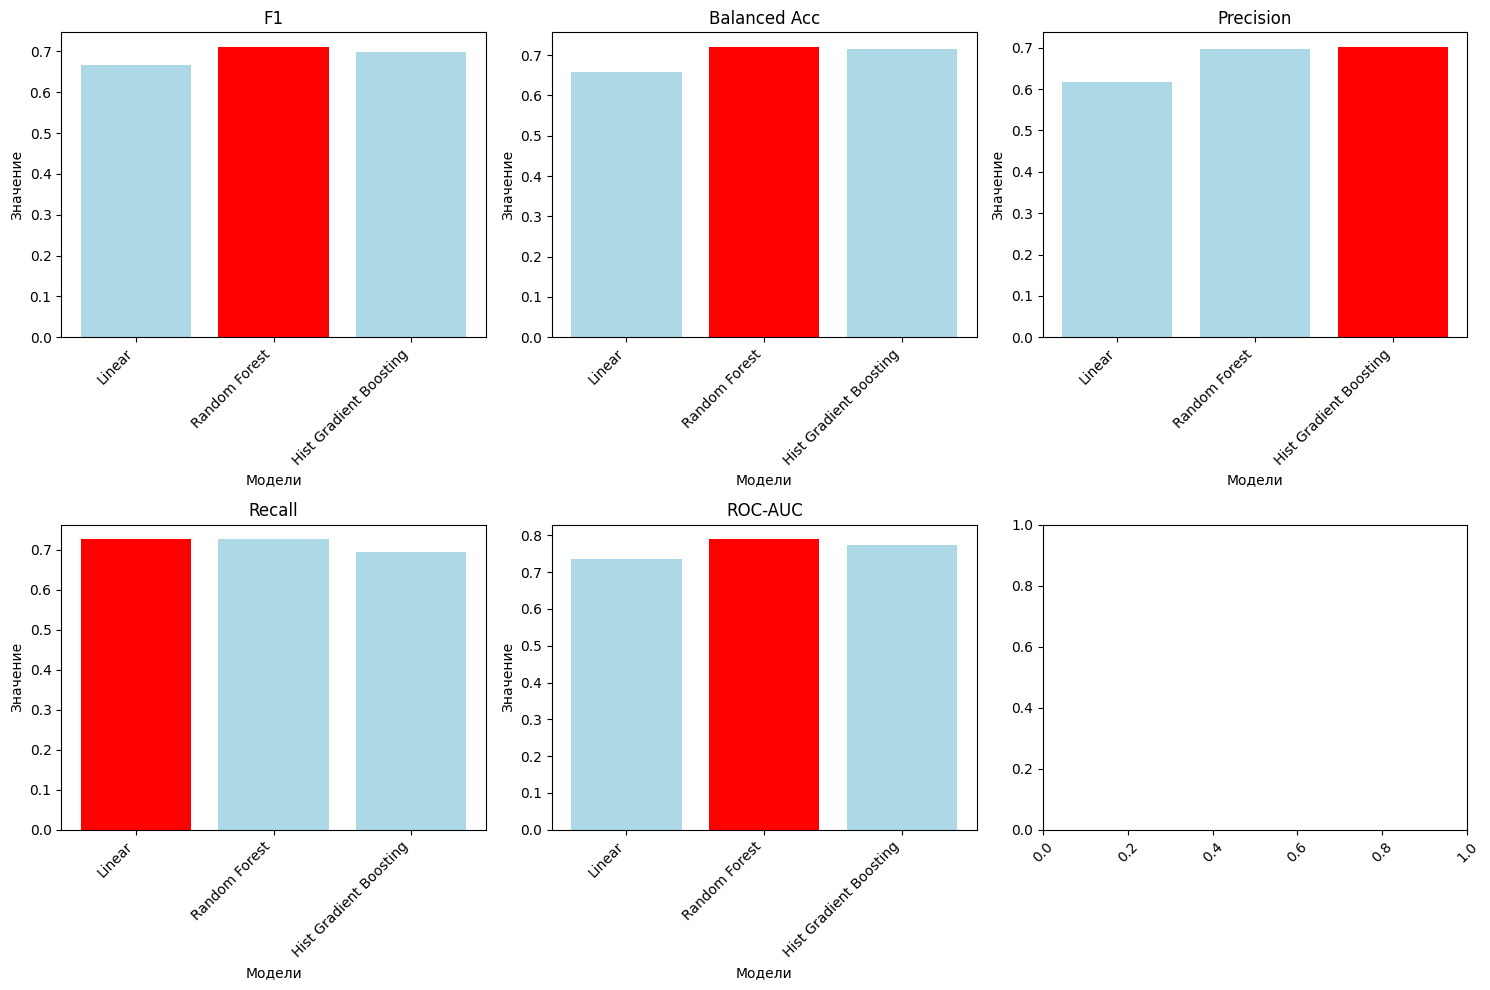

In [21]:
import matplotlib.pyplot as plt

model_names = [model_specs[m.spec_name]["name"] for m in models]
f1_values = [m.test_metrics["f1"] for m in models]
ba_values = [m.test_metrics["balanced_accuracy"] for m in models]
pr_values = [m.test_metrics["precision"] for m in models]
recall_values = [m.test_metrics["recall"] for m in models]
roc_values = [m.test_metrics["roc_auc"] for m in models]
values = [f1_values, ba_values, pr_values, recall_values, roc_values]
titles = ["F1", "Balanced Acc", "Precision", "Recall", "ROC-AUC"]

x = np.arange(len(model_names))
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

best_est = []

for i, (label, vals) in enumerate(zip(titles, values)):
    best_m = max(vals)
    best_i = vals.index(best_m)
    best_est.append(model_names[best_i])
    col = "red"

    colors = ["lightblue"] * len(model_names)
    colors[best_i] = col

    axes[i // 3][i % 3].bar(x, vals, color=colors)
    axes[i // 3][i % 3].set_xlabel("Модели")
    axes[i // 3][i % 3].set_ylabel("Значение")
    axes[i // 3][i % 3].set_xticks(x)
    axes[i // 3][i % 3].set_xticklabels(model_names, rotation=45, ha="right")
    axes[i // 3][i % 3].set_title(label)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Определяем лучшую модель голосованием

In [22]:
from collections import Counter


cnt = Counter(best_est)
best_model = cnt.most_common()

print(f"Рейтинг моделей: ")
for m, c in best_model:
    print(f"\t{m}: {c}")

Рейтинг моделей: 
	Random Forest: 3
	Hist Gradient Boosting: 1
	Linear: 1


## Важность признаков: топ-3 модели

- по результатам сравнения на test выбираем 3 лучшие модели по ROC-AUC
- переобучаем пайплайны с уже найденными гиперпараметрами
- строим один совмещённый график -  сравнение важности признаков

Топ-3 по roc_auc (test):
  - Random Forest: 0.789
  - Hist Gradient Boosting: 0.775
  - Linear: 0.735


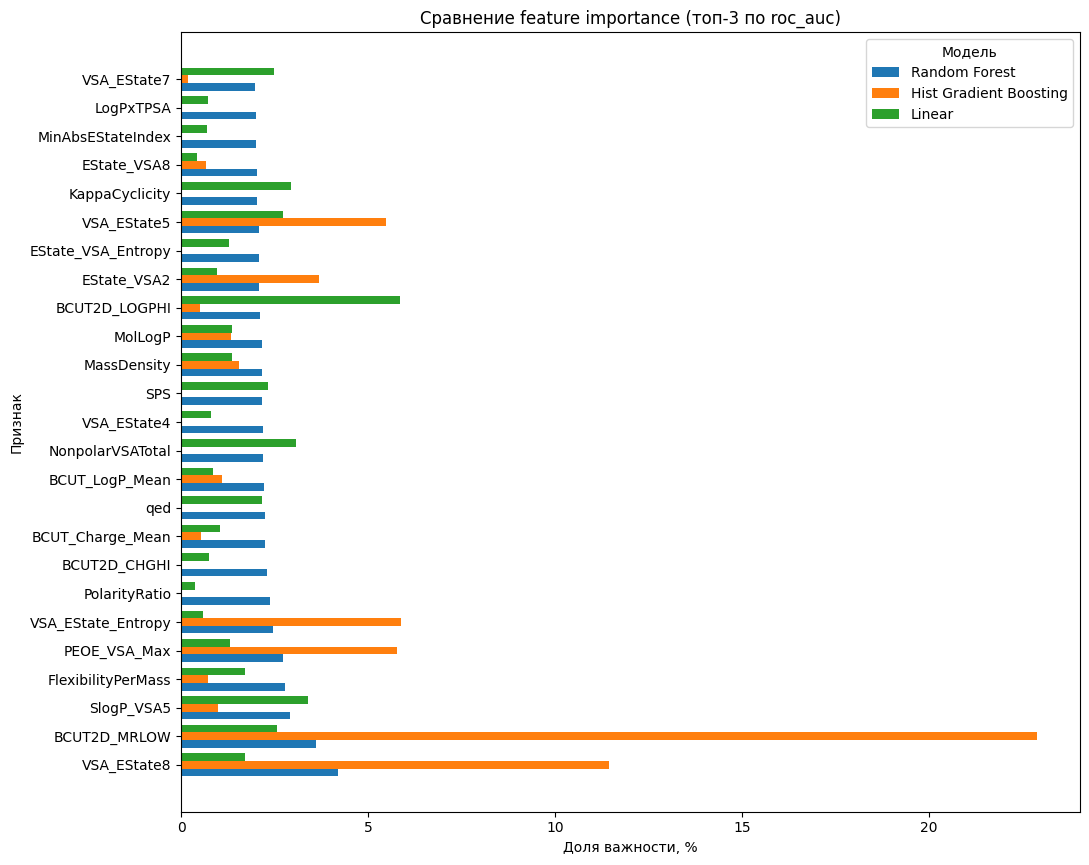

In [23]:
from sklearn.inspection import permutation_importance


METRIC = "roc_auc"


def feature_importance(fitted_pipe, X_ref, y_ref, feature_names):
    est = fitted_pipe.named_steps["model"]
    if hasattr(est, "feature_importances_"):
        vals = est.feature_importances_
    elif hasattr(est, "coef_"):
        coef = np.asarray(est.coef_)
        vals = np.abs(coef.ravel()) if coef.ndim == 1 else np.mean(np.abs(coef), axis=0)
    else:
        perm = permutation_importance(
            fitted_pipe,
            X_ref,
            y_ref,
            n_repeats=10,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            scoring=METRIC,
        )
        vals = perm.importances_mean
    return pd.Series(vals, index=feature_names)


from sklearn.base import clone


def fit_with_best_params(spec_name, best_params):
    pipe = clone(model_specs[spec_name]["pipeline"])
    pipe.set_params(**best_params)
    pipe.fit(dataset.X_train, dataset.y_train)
    return pipe


feature_names = list(dataset.X_train.columns)
top_models = sorted(models, key=lambda m: m.test_metrics[METRIC], reverse=True)[:3]

importance_df = pd.DataFrame(index=feature_names)

print(f"Топ-3 по {METRIC} (test):")
for m in top_models:
    name = model_specs[m.spec_name]["name"]
    print(f"  - {name}: {m.test_metrics[METRIC]:.3f}")
    fitted = fit_with_best_params(m.spec_name, m.best_params)
    importance_df[name] = feature_importance(
        fitted, dataset.X_test, dataset.y_test, feature_names
    )

# доля важности в % по каждой модели (сумма по столбцу = 100)
importance_notneg = importance_df.clip(lower=0)
importance_pct = importance_notneg.div(importance_notneg.sum(axis=0), axis=1) * 100

# топ-25 признаков по лучшей модели; те же признаки — у двух остальных
best_model_name = model_specs[top_models[0].spec_name]["name"]
plot_feats = importance_pct[best_model_name].sort_values(ascending=False).head(25).index
plot_df = importance_pct.loc[plot_feats]

fig, ax = plt.subplots(figsize=(11, max(6, 0.35 * len(plot_df))))
y = np.arange(len(plot_df))
bar_h = 0.8 / plot_df.shape[1]

for i, col in enumerate(plot_df.columns):
    offset = (i - (plot_df.shape[1] - 1) / 2) * bar_h
    ax.barh(y + offset, plot_df[col].values, height=bar_h, label=col)

ax.set_yticks(y)
ax.set_yticklabels(plot_df.index)
ax.set_xlabel("Доля важности, %")
ax.set_ylabel("Признак")
ax.set_title(f"Сравнение feature importance (топ-3 по {METRIC})")
ax.legend(title="Модель", loc="upper right")
plt.tight_layout()
plt.show()